In [1]:
# First, install the neuralforecast package
#!pip install neuralforecast

import pandas as pd
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data


df = pd.read_csv('nl_monthly.csv')
df


,utc_timestamp,NL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00+00:00,392469.583333
1,2015-02-01 00:00:00+00:00,336715.625000
2,2015-03-01 00:00:00+00:00,353968.541667
3,2015-04-01 00:00:00+00:00,319292.750000
4,2015-05-01 00:00:00+00:00,313571.083333
5,2015-06-01 00:00:00+00:00,315609.458333
6,2015-07-01 00:00:00+00:00,325886.958333
7,2015-08-01 00:00:00+00:00,319762.666667
8,2015-09-01 00:00:00+00:00,323992.708333
9,2015-10-01 00:00:00+00:00,350157.250000


## Training

In [3]:
# Select data for training # 
fra = '2016'
til = '2019'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'y'})
trainData['unique_id'] = 'METER_01' # Identitas unik
trainData = trainData[['unique_id', 'ds', 'y']]
trainData['ds'] = pd.to_datetime(trainData['ds'])
trainData

,unique_id,ds,y
12,METER_01,2016-01-01 00:00:00+00:00,428339.958333
13,METER_01,2016-02-01 00:00:00+00:00,398346.333333
14,METER_01,2016-03-01 00:00:00+00:00,409714.125000
15,METER_01,2016-04-01 00:00:00+00:00,370846.916667
16,METER_01,2016-05-01 00:00:00+00:00,375824.250000
17,METER_01,2016-06-01 00:00:00+00:00,376493.083333
18,METER_01,2016-07-01 00:00:00+00:00,382653.208333
19,METER_01,2016-08-01 00:00:00+00:00,374785.875000
20,METER_01,2016-09-01 00:00:00+00:00,383794.416667
21,METER_01,2016-10-01 00:00:00+00:00,401579.583333


In [4]:
len(trainData)

36

## Validatian


In [5]:
# Select data for validation # 
fra = '2019'
til = '2020'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,actual
48,2019-01-01 00:00:00+00:00,445540.166667
49,2019-02-01 00:00:00+00:00,391549.916667
50,2019-03-01 00:00:00+00:00,417876.916667
51,2019-04-01 00:00:00+00:00,373638.916667
52,2019-05-01 00:00:00+00:00,376835.625000
53,2019-06-01 00:00:00+00:00,360165.958333
54,2019-07-01 00:00:00+00:00,382177.208333
55,2019-08-01 00:00:00+00:00,377412.833333
56,2019-09-01 00:00:00+00:00,373280.958333
57,2019-10-01 00:00:00+00:00,408227.666667


In [6]:
len(validData)

12

## Forecast

In [7]:
# 3. Konfigurasi Model
# h: berapa langkah ke depan yang ingin diprediksi
# input_size: berapa langkah ke belakang yang dilihat model
horizon = len(validData)  # Contoh: prediksi 24 jam ke depan
model = NHITS(
    h=horizon,
    input_size=len(trainData), 
    #input_size=horizon*5, 
    start_padding_enabled=True,  # Melihat tren 1 minggu terakhir
    loss=MAE(),                  # Metrik evaluasi
    max_steps=1000,               # Jumlah training iterations
    n_freq_downsample=[12, 6, 1], # Menangkap pola harian, 12-jam, dan jam-jaman
    early_stop_patience_steps=10  # Berhenti jika akurasi tidak membaik
)


Seed set to 1


In [8]:
# 4. Inisialisasi dan Training

nf = NeuralForecast(models=[model], freq='MS')

nf.fit(df=trainData, val_size=horizon)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.5 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_steps=1000` reached.


In [9]:
# 5. Forecasting
fcst_df = nf.predict()
fcst_df


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


,unique_id,ds,NHITS
0,METER_01,2019-01-01 00:00:00+00:00,451862.40625
1,METER_01,2019-02-01 00:00:00+00:00,460187.59375
2,METER_01,2019-03-01 00:00:00+00:00,462112.93750
3,METER_01,2019-04-01 00:00:00+00:00,471353.18750
4,METER_01,2019-05-01 00:00:00+00:00,460071.84375
5,METER_01,2019-06-01 00:00:00+00:00,458855.96875
6,METER_01,2019-07-01 00:00:00+00:00,458669.12500
7,METER_01,2019-08-01 00:00:00+00:00,461138.31250
8,METER_01,2019-09-01 00:00:00+00:00,455299.06250
9,METER_01,2019-10-01 00:00:00+00:00,450534.21875


# Merge DataFrame

In [10]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')

In [11]:
result

,unique_id,ds,NHITS,actual
0,METER_01,2019-01-01 00:00:00+00:00,451862.40625,445540.166667
1,METER_01,2019-02-01 00:00:00+00:00,460187.59375,391549.916667
2,METER_01,2019-03-01 00:00:00+00:00,462112.93750,417876.916667
3,METER_01,2019-04-01 00:00:00+00:00,471353.18750,373638.916667
4,METER_01,2019-05-01 00:00:00+00:00,460071.84375,376835.625000
5,METER_01,2019-06-01 00:00:00+00:00,458855.96875,360165.958333
6,METER_01,2019-07-01 00:00:00+00:00,458669.12500,382177.208333
7,METER_01,2019-08-01 00:00:00+00:00,461138.31250,377412.833333
8,METER_01,2019-09-01 00:00:00+00:00,455299.06250,373280.958333
9,METER_01,2019-10-01 00:00:00+00:00,450534.21875,408227.666667


In [12]:

import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['NHITS']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['NHITS'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.1731 rMAE: 0.1570 


In [13]:
city = 'Monthly The Netherland NHITS'

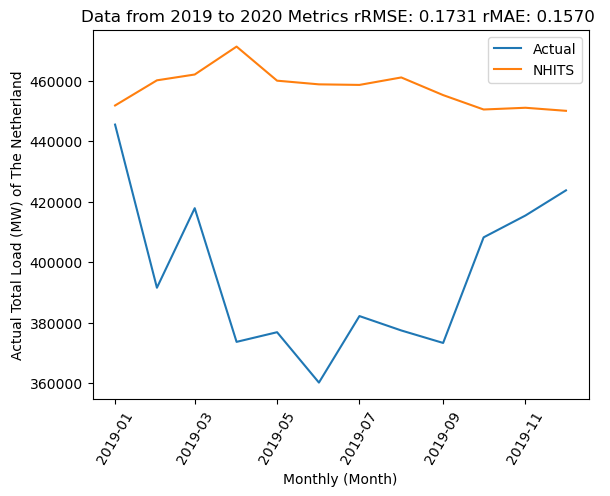

In [14]:
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['NHITS'],label='NHITS')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Monthly (Month)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of The Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
